<a href="https://colab.research.google.com/github/moosabhat7893/parkinson-gait-cnn/blob/main/gait_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0
Found files: ['/content/S01R02.txt', '/content/S05R02.txt', '/content/S02R02.txt', '/content/S06R02.txt', '/content/S02R01.txt', '/content/S03R02.txt', '/content/S03R01.txt', '/content/S08R01.txt', '/content/S06R01.txt', '/content/S01R01.txt', '/content/S07R02.txt', '/content/S05R01.txt', '/content/S09R01.txt', '/content/S10R01.txt', '/content/S03R03.txt', '/content/S04R01.txt', '/content/S07R01.txt']
Combined dataset shape: (1917887, 11)
Features shape: (1917887, 9)
Labels shape: (1917887,)
Segmented shape: (29965, 128, 9) (29965,)
Train: (23972, 128, 9) Test: (5993, 128, 9)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518,531 (1.98 MB)

 Trainable params: 518,531 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7603 - loss: 0.5694 - val_accuracy: 0.8190 - val_loss: 0.4315
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8234 - loss: 0.3975 - val_accuracy: 0.8375 - val_loss: 0.3883
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8407 - loss: 0.3706 - val_accuracy: 0.8543 - val_loss: 0.3487
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8523 - loss: 0.3364 - val_accuracy: 0.8522 - val_loss: 0.3415
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8647 - loss: 0.3081 - val_accuracy: 0.8575 - val_loss: 0.3348
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8716 - loss: 0.2948 - val_accuracy: 0.8673 - val_loss: 0.3033
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8834 - loss: 0.2684 - val_accuracy: 0.8772 - val_loss: 0.3065
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8945 - loss: 0.2501 - val_accuracy: 0

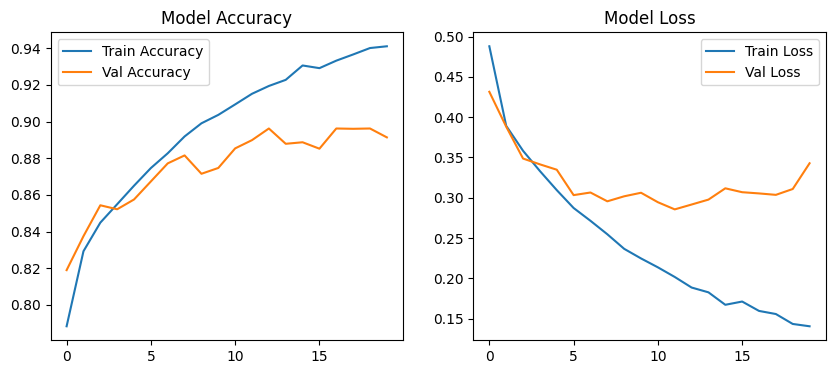

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8935 - loss: 0.3310

 Test Accuracy: 89.14% | Test Loss: 0.3428


In [3]:

import tensorflow as tf
print("TensorFlow version:", tf.__version__)


import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


files = glob.glob("/content/*.txt")
print("Found files:", files)

dfs = []
for file in files:
    temp = pd.read_csv(file, sep=" ", header=None)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print("Combined dataset shape:", df.shape)


df.columns = [
    "time",
    "LL_x","LL_y","LL_z",      # Left leg
    "RL_x","RL_y","RL_z",      # Right leg
    "WA_x","WA_y","WA_z",      # Waist
    "label"
]

# Drop empty columns if any
df = df.dropna(axis=1, how='all')


#numeric features and labels

X = df.iloc[:, 1:10].values   # 9 accelerometer features
y = df.iloc[:, -1].values     # labels (0, 1, 2)

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# Normalize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Segment data into fixed windows

def segment_signal(X, y, window_size=128, overlap=0.5):
    step = int(window_size * (1 - overlap))
    X_segments, y_segments = [], []
    for start in range(0, len(X) - window_size, step):
        end = start + window_size
        X_segments.append(X[start:end])
        y_segments.append(int(np.round(np.mean(y[start:end]))))
    return np.array(X_segments), np.array(y_segments)

X_segments, y_segments = segment_signal(X_scaled, y, window_size=128, overlap=0.5)
print("Segmented shape:", X_segments.shape, y_segments.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X_segments, y_segments, test_size=0.2, random_state=42, stratify=y_segments
)

print("Train:", X_train.shape, "Test:", X_test.shape)


model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(128, 9)),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')   # 3 classes: 0, 1, 2
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


loss, acc = model.evaluate(X_test, y_test)
print(f"\n Test Accuracy: {acc*100:.2f}% | Test Loss: {loss:.4f}")

#model.save("/content/cnn_fog_model.h5")
#print("Model saved as cnn_fog_model.h5")
